In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import os

## SLIMBRAIN

In [2]:
folder_cubi_sb = '../datasets/Madrid/hsi/'
folder_labels_sb = '../datasets/Madrid/gt/'

files_cubi_sb = sorted([f for f in os.listdir(folder_cubi_sb) if f.endswith('.npy')])
files_labels_sb = sorted([f for f in os.listdir(folder_labels_sb) if f.endswith('.npy')])

In [3]:
all_pixels_sb = []
all_labels_sb = []

In [4]:
for cube_file, label_file in zip(files_cubi_sb, files_labels_sb):
    cube = np.load(os.path.join(folder_cubi_sb, cube_file))
    labels = np.load(os.path.join(folder_labels_sb, label_file)) 

    pixels = cube.reshape(-1, cube.shape[2])
    labels_flat = labels.flatten()

    all_pixels_sb.append(pixels)
    all_labels_sb.append(labels_flat)

all_pixels_sb = np.vstack(all_pixels_sb)
all_labels_sb = np.hstack(all_labels_sb)

In [5]:
classi = [1,2,3,4]

firma_media_classi_sb = {}
firma_std_classi_sb = {}

for classe in classi:
    mask = all_labels_sb == classe
    firma_media_classi_sb[classe] = all_pixels_sb[mask].mean(axis=0)
    firma_std_classi_sb[classe] = all_pixels_sb[mask].std(axis=0)

In [6]:
bande_25 = np.array([659.9532721069965, 670.6901278110637, 688.8987816319119, 702.5051985740749, 713.615281118321,
                729.6524257344674, 740.6725793724072, 753.5695934015597, 768.1045986005809, 780.729784079351,
                791.9978623012679, 807.3773715362006, 817.5107698177138, 830.181604265628 , 845.0284417296846,
                855.4515077097817, 866.4974768585153, 880.2295227696292, 891.8857127447593, 899.8378701835213,
                914.4796949756168, 922.0207800957263, 931.7406509120706, 940.9482263577094, 950.6398722361428])

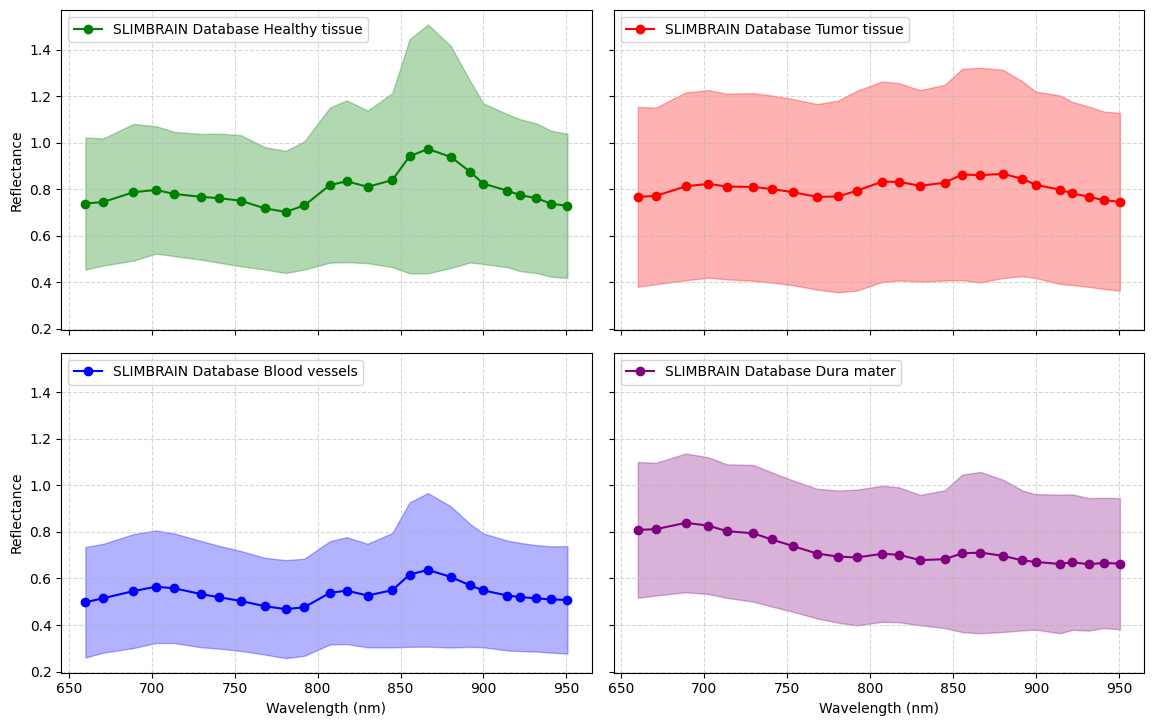

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.ravel()

class_name_sb = ['Healthy tissue', 'Tumor tissue', 'Blood vessels', 'Dura mater']

for i, classe in enumerate(classi):
    mean_sb = firma_media_classi_sb[classe]
    std_sb = firma_std_classi_sb[classe]

    ax = axes[i]
    ax.plot(bande_25, mean_sb, label=f'SLIMBRAIN Database {class_name_sb[i]}', color=['green','red','blue','purple'][i], marker='o')
    ax.fill_between(bande_25, mean_sb-std_sb, mean_sb+std_sb, alpha=0.3, color=['green','red','blue','purple'][i])
    #ax.set_title(f'{class_name[i]}')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc='upper left')

axes[0].set_ylabel('Reflectance')
axes[2].set_xlabel('Wavelength (nm)')
axes[2].set_ylabel('Reflectance')
axes[3].set_xlabel('Wavelength (nm)')

plt.tight_layout(rect=[0.03, 0.03, 1, 0.95])
plt.show()

## HELICoiD

In [8]:
folder_cubi_lp = '../datasets/LP/hsi/'
folder_labels_lp = '../datasets/LP/gt/'

files_cubi_lp = sorted([f for f in os.listdir(folder_cubi_lp) if f.endswith('.npy')])
files_labels_lp = sorted([f for f in os.listdir(folder_labels_lp) if f.endswith('.npy')])

In [9]:
all_pixels_lp = []
all_labels_lp = []

In [10]:
for cube_file, label_file in zip(files_cubi_lp, files_labels_lp):
    cube = np.load(os.path.join(folder_cubi_lp, cube_file))
    labels = np.load(os.path.join(folder_labels_lp, label_file))

    pixels = cube.reshape(-1, cube.shape[2])
    labels_flat = labels.flatten()

    all_pixels_lp.append(pixels)
    all_labels_lp.append(labels_flat)

all_pixels_lp = np.vstack(all_pixels_lp)
all_labels_lp = np.hstack(all_labels_lp)

In [11]:
classi = [1,2,3,4]

firma_media_classi_lp = {}
firma_std_classi_lp = {}

for classe in classi:
    mask = all_labels_lp == classe
    firma_media_classi_lp[classe] = all_pixels_lp[mask].mean(axis=0)
    firma_std_classi_lp[classe] = all_pixels_lp[mask].std(axis=0)

In [12]:
wavelength_lp = [
440.499, 444.137, 447.775, 451.413, 455.05, 458.688, 462.326, 465.964, 469.602,
473.24, 476.878, 480.516, 484.153, 487.791, 491.429, 495.067, 498.705, 502.343,
505.981, 509.619, 513.256, 516.894, 520.532, 524.17, 527.808, 531.446, 535.084,
538.722, 542.359, 545.997, 549.635, 553.273, 556.911, 560.549, 564.187, 567.825,
571.462, 575.1, 578.738, 582.376, 586.014, 589.652, 593.29, 596.927, 600.565,
604.203, 607.841, 611.479, 615.117, 618.755, 622.393, 626.03, 629.668, 633.306,
636.944, 640.582, 644.22, 647.858, 651.496, 655.133, 658.771, 662.409, 666.047,
669.685, 673.323, 676.961, 680.599, 684.236, 687.874, 691.512, 695.15, 698.788,
702.426, 706.064, 709.702, 713.339, 716.977, 720.615, 724.253, 727.891, 731.529,
735.167, 738.805, 742.442, 746.08, 749.718, 753.356, 756.994, 760.632, 764.27,
767.908, 771.545, 775.183, 778.821, 782.459, 786.097, 789.735, 793.373, 797.01,
800.648, 804.286, 807.924, 811.562, 815.2, 818.838, 822.476, 826.113, 829.751,
833.389, 837.027, 840.665, 844.303, 847.941, 851.579, 855.216, 858.854, 862.492,
866.13, 869.768, 873.406, 877.044, 880.682, 884.319, 887.957, 891.595, 895.233,
898.871, 902.509
]


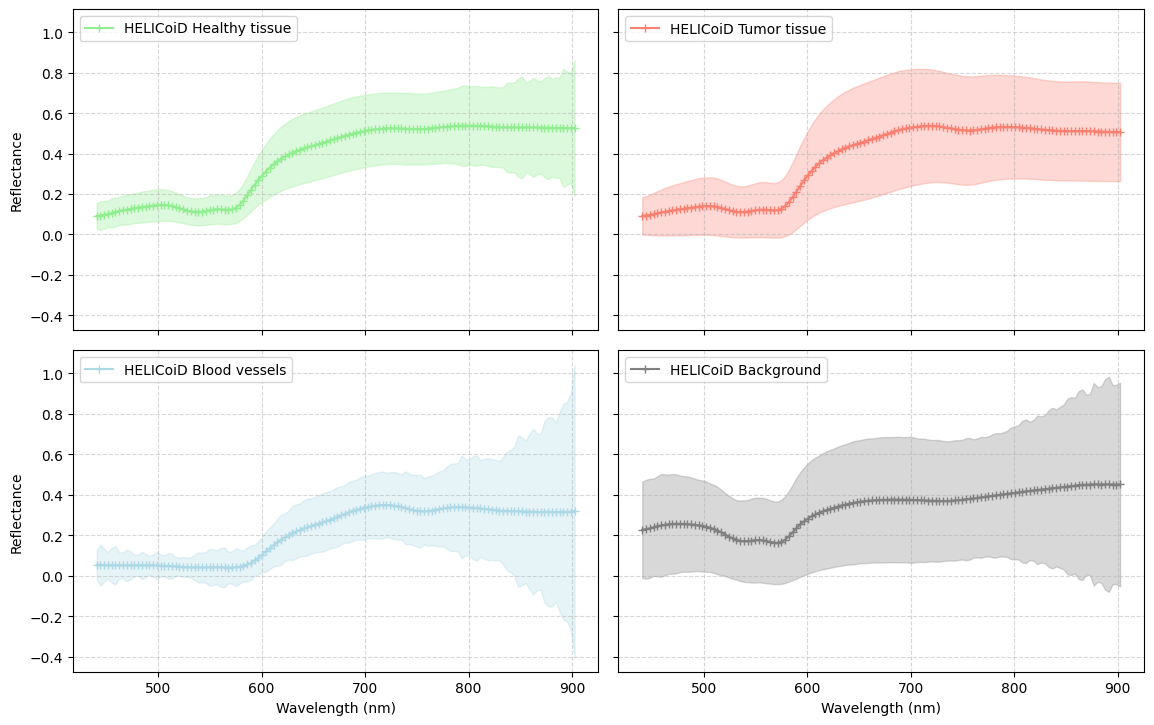

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.ravel()

class_name_lp = ['Healthy tissue', 'Tumor tissue', 'Blood vessels', 'Background']

for i, classe in enumerate(classi):
    mean_lp = firma_media_classi_lp[classe]
    std_lp = firma_std_classi_lp[classe]

    ax = axes[i]
    ax.plot(wavelength_lp, mean_lp, label=f'HELICoiD {class_name_lp[i]}', color=['lightgreen', 'salmon', 'lightblue', 'grey'][i], marker='+')
    ax.fill_between(wavelength_lp, mean_lp-std_lp, mean_lp+std_lp, alpha=0.3, color=['lightgreen', 'salmon', 'lightblue', 'grey'][i])
    #ax.set_title(f'{class_name[i]}')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc='upper left')

axes[0].set_ylabel('Reflectance')
axes[2].set_xlabel('Wavelength (nm)')
axes[2].set_ylabel('Reflectance')
axes[3].set_xlabel('Wavelength (nm)')

plt.tight_layout(rect=[0.03, 0.03, 1, 0.95])
plt.show()

## Combinazione

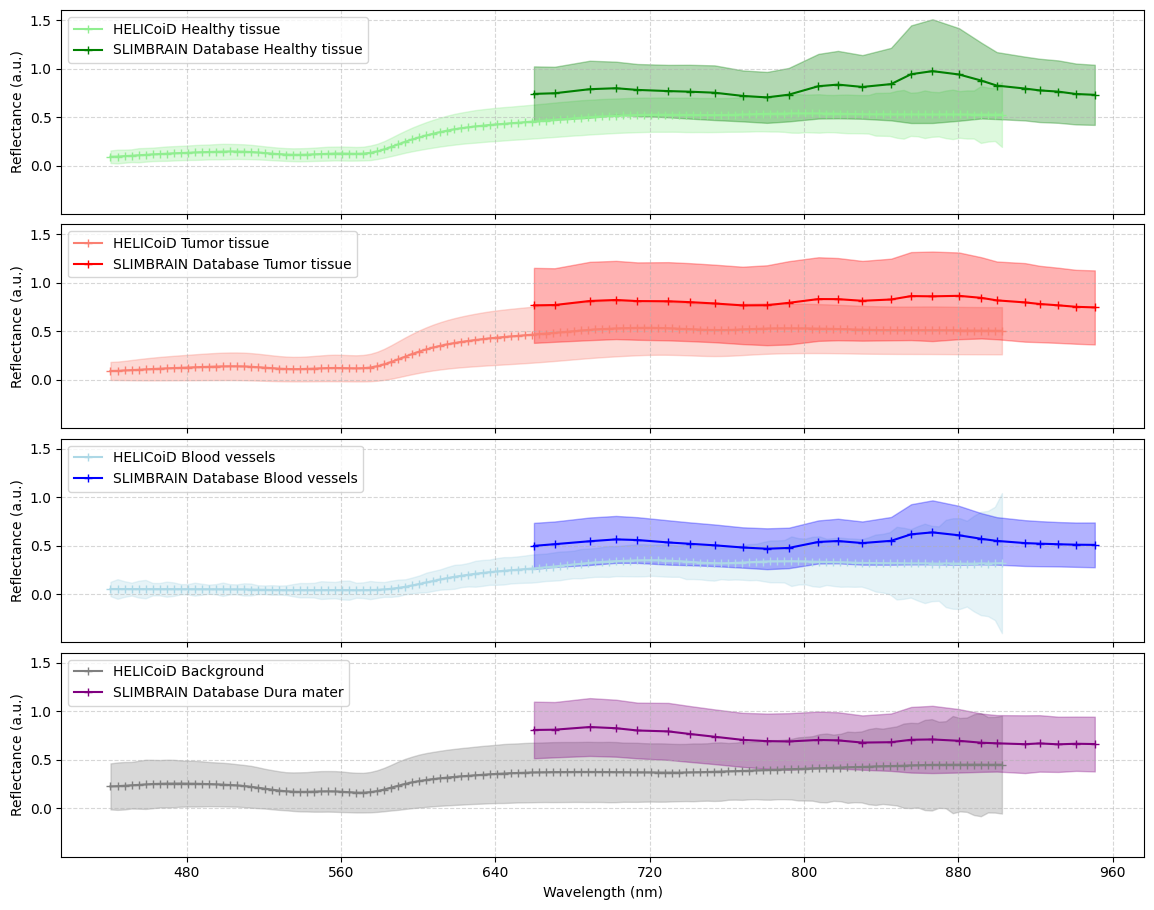

In [14]:
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True, sharey=True)
axes = axes.ravel()

for i, classe in enumerate(classi):
    mean_lp = firma_media_classi_lp[classe]
    std_lp = firma_std_classi_lp[classe]

    mean_sb = firma_media_classi_sb[classe]
    std_sb = firma_std_classi_sb[classe]

    ax = axes[i]
    ax.plot(wavelength_lp, mean_lp, label=f'HELICoiD {class_name_lp[i]}', color=['lightgreen', 'salmon', 'lightblue', 'grey'][i], marker='+')
    ax.fill_between(wavelength_lp, mean_lp-std_lp, mean_lp+std_lp, alpha=0.3, color=['lightgreen', 'salmon', 'lightblue', 'grey'][i])
    #ax.set_title(f'{class_name[i]}')
    ax.plot(bande_25, mean_sb, label=f'SLIMBRAIN Database {class_name_sb[i]}', color=['green','red','blue','purple'][i], marker='+')
    ax.fill_between(bande_25, mean_sb-std_sb, mean_sb+std_sb, alpha=0.3, color=['green','red','blue','purple'][i])

    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc='upper left')
    ax.set_ylabel('Reflectance (a.u.)')

axes[3].set_xlabel('Wavelength (nm)')
axes[3].xaxis.set_major_locator(MaxNLocator(nbins=8))

plt.tight_layout(h_pad=0.4, rect=[0.03, 0.03, 1, 0.95])
plt.savefig('spectrum_analysis.png', dpi=1200, bbox_inches='tight')
plt.show()

In [15]:
from matplotlib import colors as mcolors

In [16]:
colors_line = ['green', 'red', 'blue', 'grey']
colors_fill = ['lightgreen', 'salmon', 'lightblue', 'lightgrey']

colors_line_sb = ['green', 'red', 'blue', 'purple']
colors_fill_sb = ['lightgreen', 'salmon', 'lightblue', 'orchid']

In [17]:
def mid_color(c1, c2, alpha=0.7):
    rgb1 = mcolors.to_rgb(c1)
    rgb2 = mcolors.to_rgb(c2)
    return tuple((1-alpha)*a + alpha*b for a, b in zip(rgb1, rgb2))

colors_edge = [mid_color(colors_fill[i], colors_line[i], alpha=0.8) for i in range(4)]
colors_edge_sb = [mid_color(colors_fill_sb[i], colors_line_sb[i], alpha=0.8) for i in range(4)]

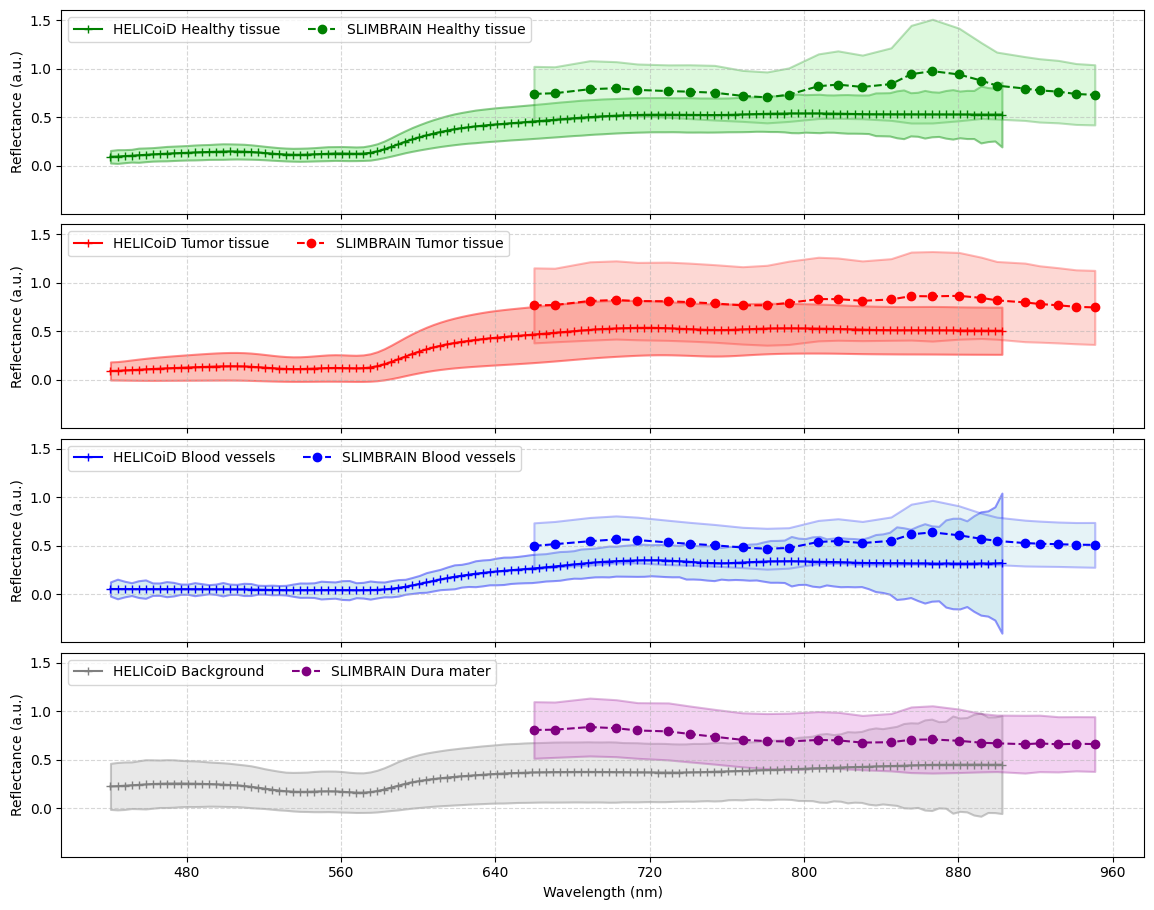

In [19]:
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True, sharey=True)
axes = axes.ravel()

for i, classe in enumerate(classi):
    mean_lp = firma_media_classi_lp[classe]
    std_lp = firma_std_classi_lp[classe]

    mean_sb = firma_media_classi_sb[classe]
    std_sb = firma_std_classi_sb[classe]

    ax = axes[i]
    ax.plot(wavelength_lp, mean_lp, label=f'HELICoiD {class_name_lp[i]}', color=colors_line[i], marker='+', linewidth=1.5)
    ax.fill_between(wavelength_lp, mean_lp-std_lp, mean_lp+std_lp, alpha=0.5, color=colors_fill[i], linewidth=1.5, edgecolor=colors_edge[i])
    #ax.set_title(f'{class_name[i]}')
    ax.plot(bande_25, mean_sb, label=f'SLIMBRAIN {class_name_sb[i]}', color=colors_line_sb[i], marker='o', linewidth=1.5, linestyle="--")
    ax.fill_between(bande_25, mean_sb-std_sb, mean_sb+std_sb, alpha=0.3, color=colors_fill_sb[i], linewidth=1.5, edgecolor=colors_edge_sb[i])

    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc='upper left', ncol=2)
    ax.set_ylabel('Reflectance (a.u.)')

axes[3].set_xlabel('Wavelength (nm)')
axes[3].xaxis.set_major_locator(MaxNLocator(nbins=8))

plt.tight_layout(h_pad=0.4, rect=[0.03, 0.03, 1, 0.95])
plt.savefig('spectrum_analysis.png', dpi=1200, bbox_inches='tight', transparent=True)
plt.show()